In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

file_path = "Photsynthesis and Stomatal Conductance Reduction Data.xlsx"
df = pd.read_excel(file_path, sheet_name="Campos-Villareal Data", skiprows=9)
df = df.rename(columns={"Salinity(mMol) (Approximate)": "salinity_mMol"})
df

,Salinity (dS·m⁻¹),salinity_mMol,Apache,Riverside,SVA1,SVA2,Percent_Baseline_Apache,Percent_Baseline_Riverside,Percent_Baseline_SVA1,Percent_Baseline_SVA2,Percent_Reduction_Percent_Baseline_Apache,Percent_Reduction_Percent_Baseline_Riverside,Percent_Reduction_Percent_Baseline_SVA1,Percent_Reduction_Percent_Baseline_SVA2,Unnamed: 14
0,0.08,0.8,5.2,5.3,5.2,4.3,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN
1,2.50,25.0,3.7,4.3,4.7,4.0,0.711538,0.811321,0.903846,0.930233,0.288462,0.188679,0.096154,0.069767,NaN
2,3.00,30.0,2.6,3.7,3.9,2.7,0.500000,0.698113,0.750000,0.627907,0.500000,0.301887,0.250000,0.372093,NaN
3,3.50,35.0,1.8,3.7,2.9,2.6,0.346154,0.698113,0.557692,0.604651,0.653846,0.301887,0.442308,0.395349,NaN


In [ ]:
# ── Model functions (threshold always explicit) ───────────────────────────────
def piecewise_model(x, slope, threshold):
    return slope * np.maximum(0.0, x - threshold)

def piecewise_power_model(x, a, b, threshold):
    """b is constrained to (0, 1] during fitting."""
    return a * np.maximum(0.0, x - threshold) ** b

# ── Cultivar series ───────────────────────────────────────────────────────────
reduction_cols = [
    "Percent_Reduction_Percent_Baseline_Apache",
    "Percent_Reduction_Percent_Baseline_Riverside",
    "Percent_Reduction_Percent_Baseline_SVA1",
    "Percent_Reduction_Percent_Baseline_SVA2",
]
cultivar_names = ["Apache", "Riverside", "SVA1", "SVA2"]

# ── Helpers ───────────────────────────────────────────────────────────────────
def _r2(y, y_pred):
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - np.sum((y - y_pred) ** 2) / ss_tot if ss_tot > 0 else np.nan

def fit_piecewise(x, y, label, threshold=None):
    """Fit piecewise linear model.
    threshold : float  → fixed at that value
    threshold : None   → fitted as a free parameter
    """
    if threshold is not None:
        fn = lambda x, slope: piecewise_model(x, slope, threshold)
        (slope,), _ = curve_fit(fn, x, y, p0=[0.05], bounds=([0], [np.inf]))
        t = threshold
    else:
        (slope, t), _ = curve_fit(
            piecewise_model, x, y, p0=[0.05, 25],
            bounds=([0, 0], [np.inf, np.inf]),
        )
    return {"Cultivar": label, "Slope": slope, "Threshold": t,
            "R2": _r2(y, piecewise_model(x, slope, t))}

def fit_piecewise_power(x, y, label, threshold=None):
    """Fit piecewise power-law model (b ≤ 1).
    threshold : float  → fixed at that value
    threshold : None   → fitted as a free parameter
    """
    if threshold is not None:
        fn = lambda x, a, b: piecewise_power_model(x, a, b, threshold)
        (a, b), _ = curve_fit(
            fn, x, y, p0=[0.05, 0.8],
            bounds=([0, 0], [np.inf, 1.0]), maxfev=10000,
        )
        t = threshold
    else:
        (a, b, t), _ = curve_fit(
            piecewise_power_model, x, y, p0=[0.05, 0.8, 25],
            bounds=([0, 0, 0], [np.inf, 1.0, np.inf]), maxfev=10000,
        )
    return {"Cultivar": label, "a": a, "b": b, "Threshold": t,
            "R2": _r2(y, piecewise_power_model(x, a, b, t))}

# ── Run fits ──────────────────────────────────────────────────────────────────
FIXED_THRESHOLD = 25  # mMol — set to None to fit threshold freely

x = df["salinity_mMol"].values
results, power_results = [], []
for col, name in zip(reduction_cols, cultivar_names):
    results.append(fit_piecewise(x, df[col].values, name, threshold=FIXED_THRESHOLD))
    power_results.append(fit_piecewise_power(x, df[col].values, name, threshold=FIXED_THRESHOLD))

x_all = np.tile(x, len(reduction_cols))
y_all = np.concatenate([df[col].values for col in reduction_cols])
results.append(fit_piecewise(x_all, y_all, "Combined", threshold=FIXED_THRESHOLD))
power_results.append(fit_piecewise_power(x_all, y_all, "Combined", threshold=FIXED_THRESHOLD))

results_df = pd.DataFrame(results).set_index("Cultivar")
power_results_df = pd.DataFrame(power_results).set_index("Cultivar")

print("=== Piecewise Linear ===")
display(results_df)
print("\n=== Piecewise Power Law ===")
display(power_results_df)

=== Piecewise Linear ===


,Slope,Threshold,R2
Cultivar,,,
Apache,0.072308,25,0.554668
Riverside,0.036226,25,0.115789
SVA1,0.045385,25,0.911478
SVA2,0.046512,25,0.765217
Combined,0.050108,25,0.527467



=== Piecewise Power Law ===


,a,b,Threshold,R2
Cultivar,,,,
Apache,0.268196,3.870231e-01,25,0.654245
Riverside,0.301887,2.126506e-09,25,0.415205
SVA1,0.066466,8.231222e-01,25,0.917424
SVA2,0.323234,8.746284e-02,25,0.960870
Combined,0.208379,3.327601e-01,25,0.618006


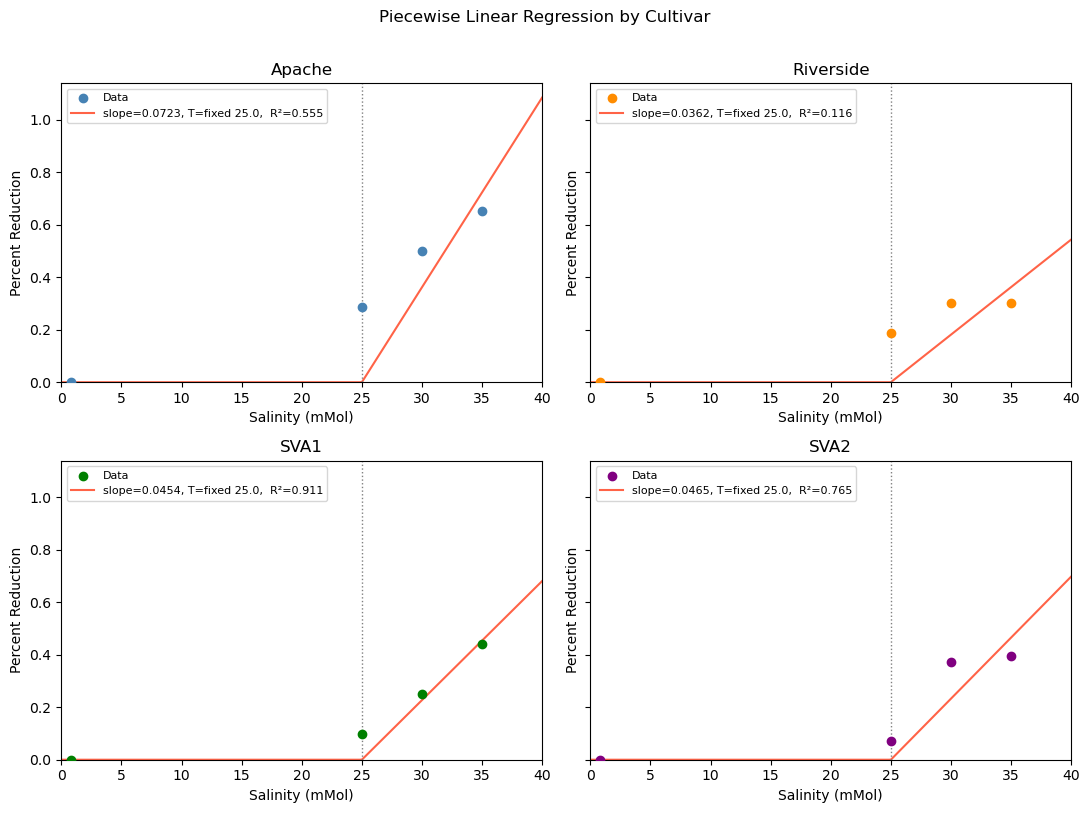

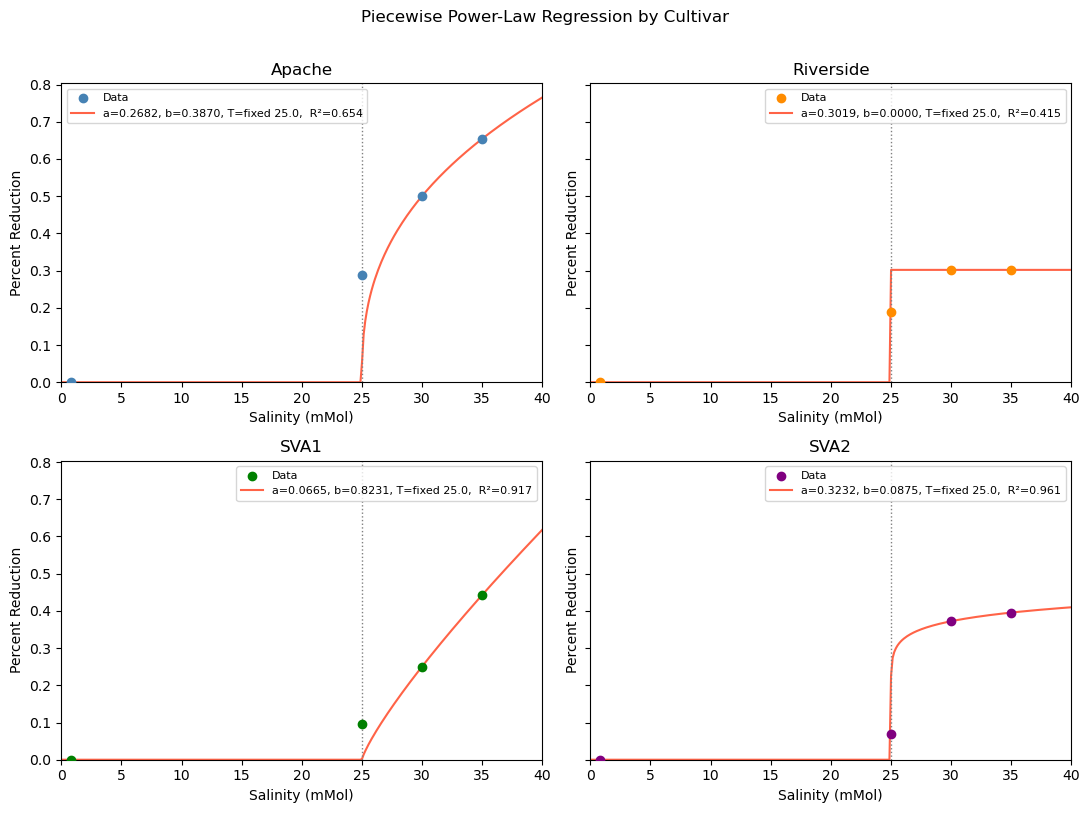

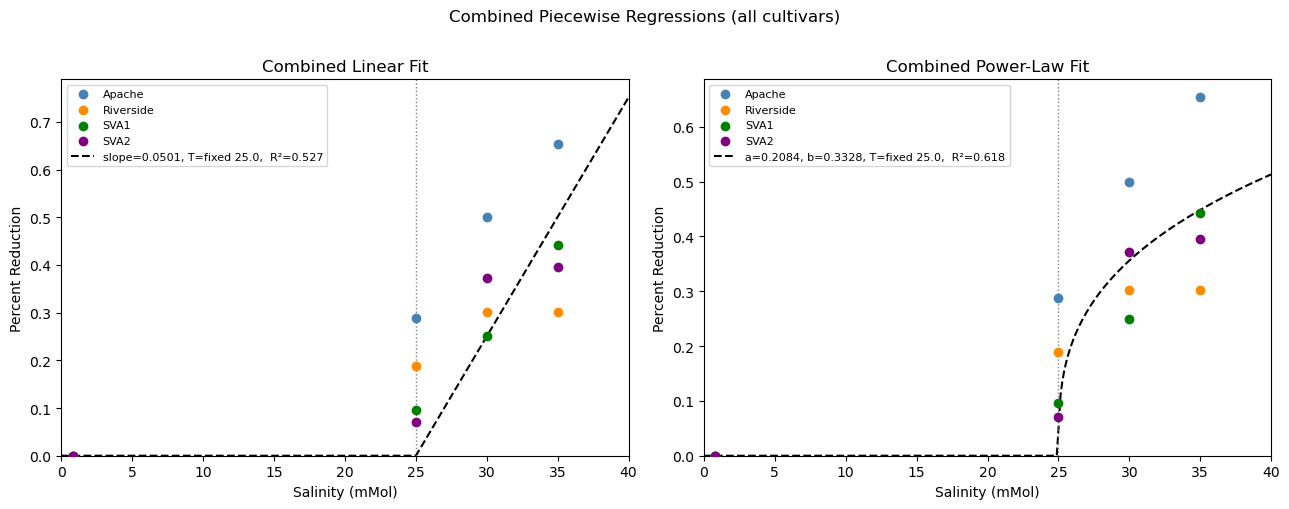

In [ ]:

x_plot = np.linspace(0, 40, 300)
colors = ["steelblue", "darkorange", "green", "purple"]
threshold_fixed = FIXED_THRESHOLD is not None

def _threshold_label(t):
    return f"T={'fixed ' if threshold_fixed else 'fit '}{t:.1f}"

# ── Per-cultivar subplots: Linear ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, col, name, color in zip(axes.flat, reduction_cols, cultivar_names, colors):
    row = results_df.loc[name]
    ax.scatter(x, df[col].values, color=color, zorder=5, label="Data")
    ax.plot(x_plot, piecewise_model(x_plot, row["Slope"], row["Threshold"]), color="tomato",
            label=f"slope={row['Slope']:.4f}, {_threshold_label(row['Threshold'])},  R²={row['R2']:.3f}")
    ax.axvline(row["Threshold"], color="gray", linestyle=":", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Salinity (mMol)")
    ax.set_ylabel("Percent Reduction")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, None)
fig.suptitle("Piecewise Linear Regression by Cultivar", y=1.01)
plt.tight_layout()
plt.show()

# ── Per-cultivar subplots: Power Law ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, col, name, color in zip(axes.flat, reduction_cols, cultivar_names, colors):
    row = power_results_df.loc[name]
    ax.scatter(x, df[col].values, color=color, zorder=5, label="Data")
    ax.plot(x_plot, piecewise_power_model(x_plot, row["a"], row["b"], row["Threshold"]), color="tomato",
            label=f"a={row['a']:.4f}, b={row['b']:.4f}, {_threshold_label(row['Threshold'])},  R²={row['R2']:.3f}")
    ax.axvline(row["Threshold"], color="gray", linestyle=":", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Salinity (mMol)")
    ax.set_ylabel("Percent Reduction")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, None)
fig.suptitle("Piecewise Power-Law Regression by Cultivar", y=1.01)
plt.tight_layout()
plt.show()

# ── Combined plots: Linear & Power Law side by side ───────────────────────────
fig2, (ax_lin, ax_pow) = plt.subplots(1, 2, figsize=(13, 5))
combined_lin = results_df.loc["Combined"]
combined_pow = power_results_df.loc["Combined"]

for col, name, color in zip(reduction_cols, cultivar_names, colors):
    ax_lin.scatter(x, df[col].values, color=color, label=name, zorder=5)
    ax_pow.scatter(x, df[col].values, color=color, label=name, zorder=5)

ax_lin.plot(x_plot, piecewise_model(x_plot, combined_lin["Slope"], combined_lin["Threshold"]), "k--",
            label=f"slope={combined_lin['Slope']:.4f}, {_threshold_label(combined_lin['Threshold'])},  R²={combined_lin['R2']:.3f}")
ax_lin.axvline(combined_lin["Threshold"], color="gray", linestyle=":", linewidth=1)

ax_pow.plot(x_plot, piecewise_power_model(x_plot, combined_pow["a"], combined_pow["b"], combined_pow["Threshold"]), "k--",
            label=f"a={combined_pow['a']:.4f}, b={combined_pow['b']:.4f}, {_threshold_label(combined_pow['Threshold'])},  R²={combined_pow['R2']:.3f}")
ax_pow.axvline(combined_pow["Threshold"], color="gray", linestyle=":", linewidth=1)

for ax, title in [(ax_lin, "Combined Linear Fit"), (ax_pow, "Combined Power-Law Fit")]:
    ax.set_xlabel("Salinity (mMol)")
    ax.set_ylabel("Percent Reduction")
    ax.set_title(title)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, None)
    ax.legend(fontsize=8)

fig2.suptitle("Combined Piecewise Regressions (all cultivars)", y=1.01)
plt.tight_layout()
plt.show()

=== Piecewise Linear (threshold fitted) ===


,Slope,Threshold,R2
Cultivar,,,
Apache,0.036538,16.842105,0.997695
Riverside,0.011321,6.666667,0.964912
SVA1,0.034615,22.407407,0.997798
SVA2,0.032558,21.428572,0.895652
Combined,0.028758,18.813529,0.774847



=== Piecewise Power Law (threshold fitted) ===


,a,b,Threshold,R2
Cultivar,,,,
Apache,0.162217,0.545556,22.127674,1.000000
Riverside,0.285765,0.027848,25.000000,0.999718
SVA1,0.071099,0.800530,25.190038,0.917424
SVA2,0.323234,0.087463,25.000000,1.000000
Combined,0.190154,0.362887,24.370381,0.786335


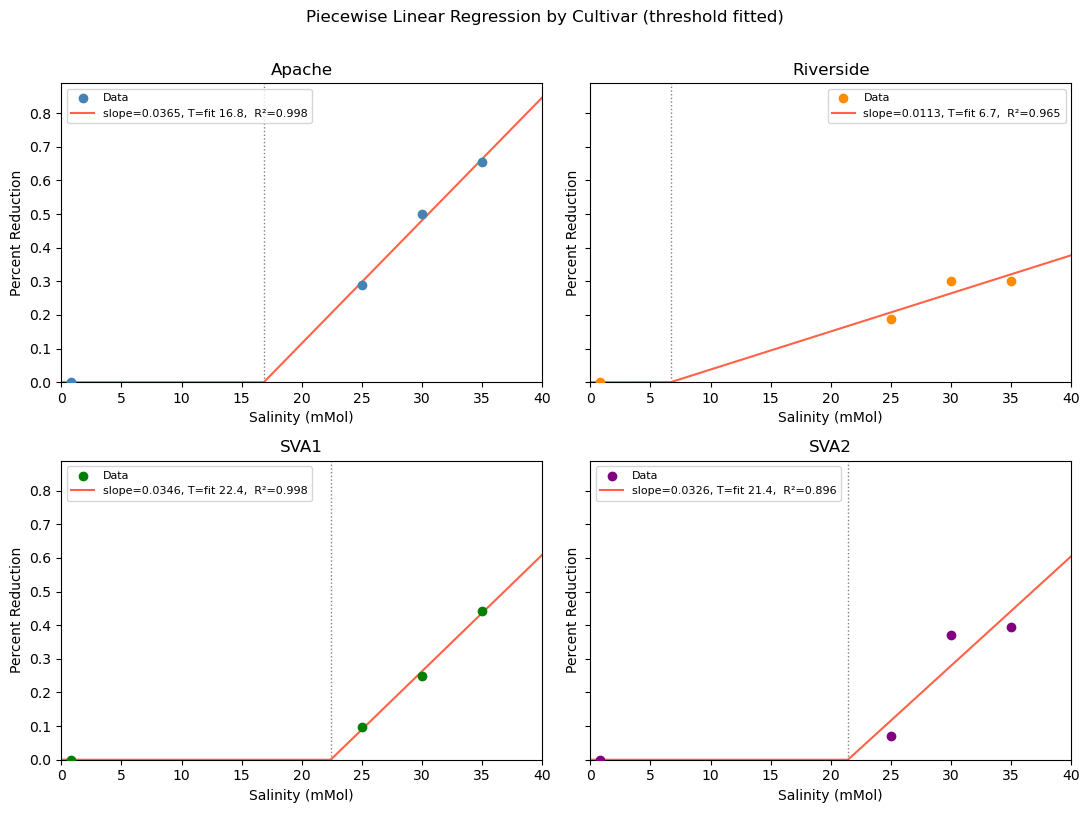

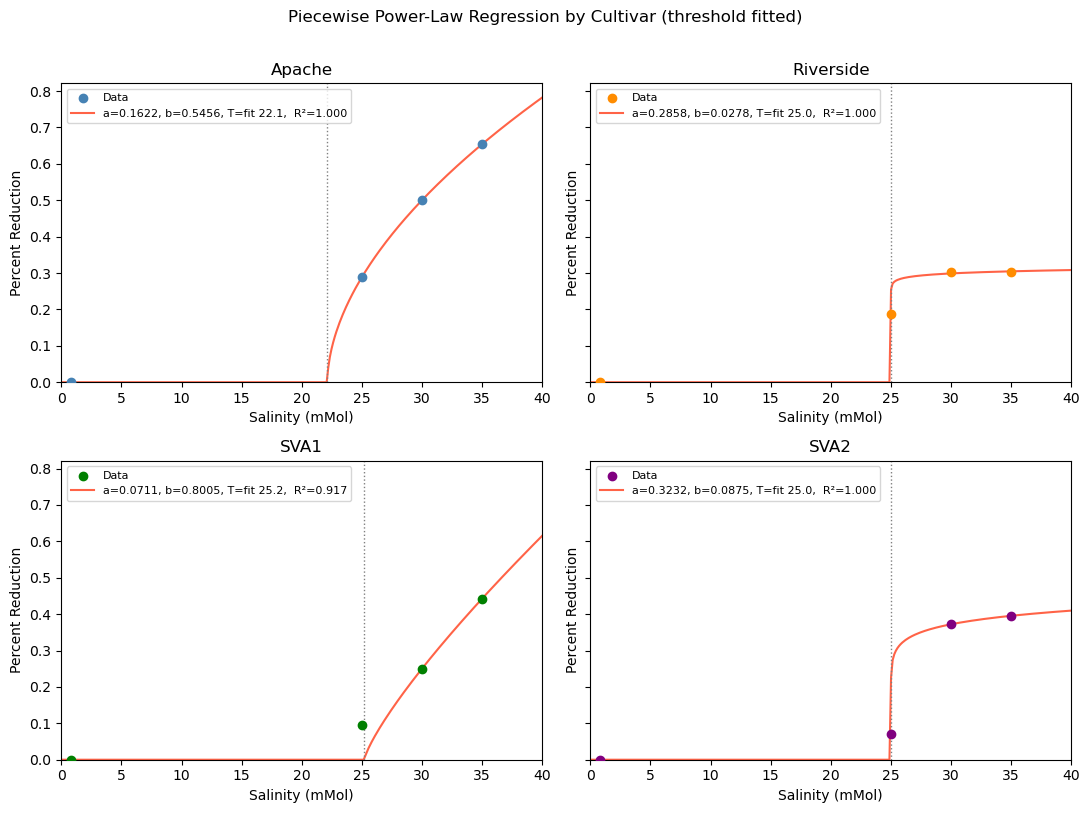

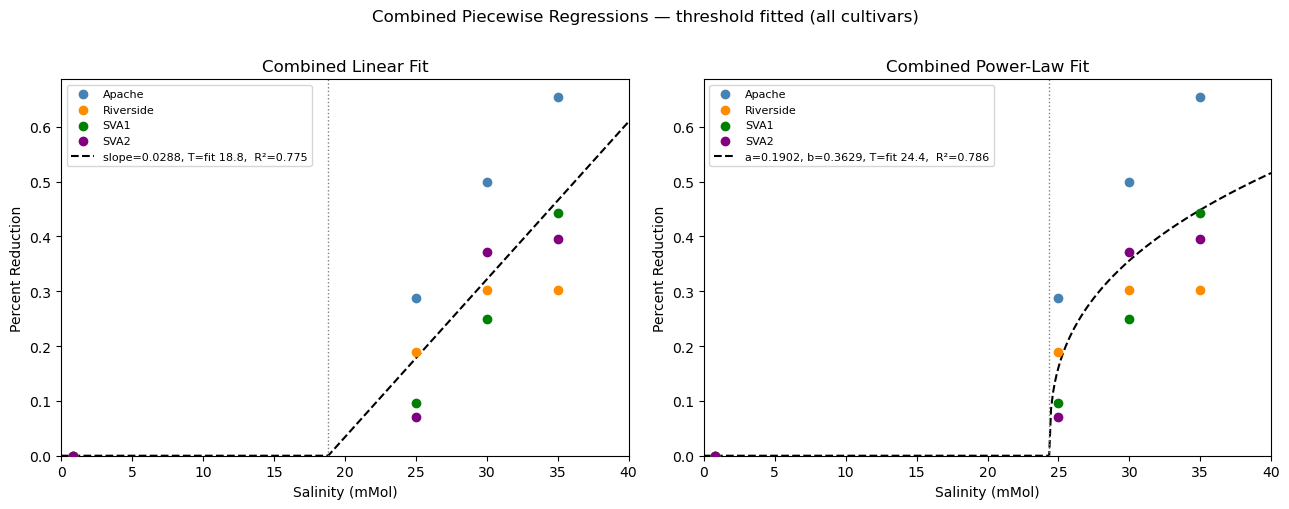

In [10]:
#    ── Fits with threshold as a free parameter ───────────────────────────────────
free_results, free_power_results = [], []
for col, name in zip(reduction_cols, cultivar_names):
    free_results.append(fit_piecewise(x, df[col].values, name, threshold=None))
    free_power_results.append(fit_piecewise_power(x, df[col].values, name, threshold=None))

free_results.append(fit_piecewise(x_all, y_all, "Combined", threshold=None))
free_power_results.append(fit_piecewise_power(x_all, y_all, "Combined", threshold=None))

free_results_df = pd.DataFrame(free_results).set_index("Cultivar")
free_power_results_df = pd.DataFrame(free_power_results).set_index("Cultivar")

print("=== Piecewise Linear (threshold fitted) ===")
display(free_results_df)
print("\n=== Piecewise Power Law (threshold fitted) ===")
display(free_power_results_df)

# ── Plots ─────────────────────────────────────────────────────────────────────
x_plot = np.linspace(0, 40, 300)
colors = ["steelblue", "darkorange", "green", "purple"]

def _free_threshold_label(t):
    return f"T=fit {t:.1f}"

# Per-cultivar: Linear
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, col, name, color in zip(axes.flat, reduction_cols, cultivar_names, colors):
    row = free_results_df.loc[name]
    ax.scatter(x, df[col].values, color=color, zorder=5, label="Data")
    ax.plot(x_plot, piecewise_model(x_plot, row["Slope"], row["Threshold"]), color="tomato",
            label=f"slope={row['Slope']:.4f}, {_free_threshold_label(row['Threshold'])},  R²={row['R2']:.3f}")
    ax.axvline(row["Threshold"], color="gray", linestyle=":", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Salinity (mMol)")
    ax.set_ylabel("Percent Reduction")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, None)
fig.suptitle("Piecewise Linear Regression by Cultivar (threshold fitted)", y=1.01)
plt.tight_layout()
plt.show()

# Per-cultivar: Power Law
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, col, name, color in zip(axes.flat, reduction_cols, cultivar_names, colors):
    row = free_power_results_df.loc[name]
    ax.scatter(x, df[col].values, color=color, zorder=5, label="Data")
    ax.plot(x_plot, piecewise_power_model(x_plot, row["a"], row["b"], row["Threshold"]), color="tomato",
            label=f"a={row['a']:.4f}, b={row['b']:.4f}, {_free_threshold_label(row['Threshold'])},  R²={row['R2']:.3f}")
    ax.axvline(row["Threshold"], color="gray", linestyle=":", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Salinity (mMol)")
    ax.set_ylabel("Percent Reduction")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, None)
fig.suptitle("Piecewise Power-Law Regression by Cultivar (threshold fitted)", y=1.01)
plt.tight_layout()
plt.show()

# Combined: Linear & Power Law side by side
fig2, (ax_lin, ax_pow) = plt.subplots(1, 2, figsize=(13, 5))
combined_lin = free_results_df.loc["Combined"]
combined_pow = free_power_results_df.loc["Combined"]

for col, name, color in zip(reduction_cols, cultivar_names, colors):
    ax_lin.scatter(x, df[col].values, color=color, label=name, zorder=5)
    ax_pow.scatter(x, df[col].values, color=color, label=name, zorder=5)

ax_lin.plot(x_plot, piecewise_model(x_plot, combined_lin["Slope"], combined_lin["Threshold"]), "k--",
            label=f"slope={combined_lin['Slope']:.4f}, {_free_threshold_label(combined_lin['Threshold'])},  R²={combined_lin['R2']:.3f}")
ax_lin.axvline(combined_lin["Threshold"], color="gray", linestyle=":", linewidth=1)

ax_pow.plot(x_plot, piecewise_power_model(x_plot, combined_pow["a"], combined_pow["b"], combined_pow["Threshold"]), "k--",
            label=f"a={combined_pow['a']:.4f}, b={combined_pow['b']:.4f}, {_free_threshold_label(combined_pow['Threshold'])},  R²={combined_pow['R2']:.3f}")
ax_pow.axvline(combined_pow["Threshold"], color="gray", linestyle=":", linewidth=1)

for ax, title in [(ax_lin, "Combined Linear Fit"), (ax_pow, "Combined Power-Law Fit")]:
    ax.set_xlabel("Salinity (mMol)")
    ax.set_ylabel("Percent Reduction")
    ax.set_title(title)
    ax.set_xlim(0, 40)
    ax.set_ylim(0, None)
    ax.legend(fontsize=8)

fig2.suptitle("Combined Piecewise Regressions — threshold fitted (all cultivars)", y=1.01)
plt.tight_layout()
plt.show()